# Week 10 - Introduction to Modeling

# 1. Lesson

Last week, we reviewed one model: linear regression.  This week, we are going to review another, called random forest.  The random forest model builds many decision trees, then averages their estimates to make a prediction.

You will also perform:
* Cross-validation
* Hyperparameter tuning
* A performance metric (root mean squared error)

### How does random forest work?

A random forest is a set of decision trees.  Let's say we use n_estimators = 100 decision trees, and we have ten features.  Then each decision tree is built so that a given branch gets about three (sqrt(10)) features to choose from.  It starts from the top of the tree, selects the best feature, then proceeds to the next nodes.  The best feature is the one that minimizes the mean squared error, which must be computed for both branches, weighted according to the probability of each branch, and then summed over both branches.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

Here, we build three series of random numbers between 0 and 1.  We use a somewhat arbitrary formula to construct the synthetic data.  The fourth value (the target) equals the first series minus twice the second, with the whole then being multiplied by the third series.  If we stopped here, the target would be completely dependent on the three feature series - it would be easy to predict.  However, we then add a random normal distribution to make the prediction harder.

There are a train series and a test series, with different features ("a" and "b"), and with different random normal data added.  This tests whether our model can predict new data.  We fit to the "a" features using the train_target, then predict the test_target using the "b" features.

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

As expected, the RMSE is smallest when predicting the training data, larger when predicting the testing data, and largest when comparing random (shuffled) data instead of using a prediction.  In the last case, there is no attempt to make a good prediction.  The small RMSE when predicting the training data indicates that the model has "memorized" the training data to some degree.

In [3]:
print("RMSE when predicting training data:")
print(root_mean_squared_error(rf.predict(train_df.values), train_target))
print("RMSE when predicting testing data:")
print(root_mean_squared_error(rf.predict(test_df.values), test_target))
test_target_shuffle = test_target.copy()
np.random.shuffle(test_target_shuffle)
print("RMSE with random predictions:")
print(root_mean_squared_error(test_target_shuffle, test_target))

RMSE when predicting training data:
0.4044690379054401
RMSE when predicting testing data:
1.0666204347667476
RMSE with random predictions:
5.262103337484077


Next, we perform a Grid Search over various parameters.  We've used a small number of parameters here, but you could add more.  The first parameter, n_estimators, shows the number of decision trees in the random forest.  The second, max_depth, is the maximum depth of each tree.  By picking three n_estimators values (10, 33, 100) and three max_depth values (2, 4, None), we allow for nine parameter combinations.  For example, (n_estimators = 10, max_depth = 2) is a combination.  The grid search tries all nine combinations and uses cross validation to choose the best one.  This is done below.

### What is cross validation?

Cross validation is a way to find out which parameter combination is the best.  With 5-fold cross validation (the default) we divide the data into five equal-sized groups.  Four of them are used as training data and the fifth is testing data.  The score (in this case the root mean squared error) on the testing data is recorded.  This is done for each split: that is, each fifth is taken out and used as testing data; then, the five root mean squared errors (from taking out the five fifths, one at a time) are averaged.

We now have root mean squared error value for each parameter combination, allowing us to choose the best combination.

In [4]:
np.random.seed(0)
gcv = GridSearchCV(estimator = RandomForestRegressor(), param_grid = {"n_estimators": [10, 33, 100], "max_depth": [2, 4, None]}, \
                   scoring = "neg_root_mean_squared_error")
gcv.fit(train_df.values, train_target)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [2, 4, None],
                         'n_estimators': [10, 33, 100]},
             scoring='neg_root_mean_squared_error')

In [5]:
print(gcv.best_estimator_)
print(gcv.best_params_)
print(gcv.best_score_)

RandomForestRegressor()
{'max_depth': None, 'n_estimators': 100}
-1.0851467026495314


In [6]:
gcv.cv_results_["mean_test_score"] # There are nine scores, one for each of the 3 x 3 hyperparameter combinations

array([-2.27296628, -2.26369708, -2.26370023, -1.56063403, -1.52732923,
       -1.52615891, -1.12289873, -1.09373797, -1.0851467 ])

### Why does n_estimators grow like 10, 33, 100 instead of like 1, 50, 100?

First of all, we can make it grow however we want.  The question is why we chose 10, 33, 100.  The idea here is that when you have no idea what is the appropriate number, you should pick guesses that grow exponentially.  For example, suppose you are trying to guess the height of a particular tree.  You look online and find that redwoods grow to 400 feet high, while bonsai trees may be as short as six inches.  If you get three guesses, you could guess: one foot, 200 feet, 400 feet.  These guesses would be linearly spaced out.  However, the 200 foot guess feels wrong - it's still very tall.  Most trees don't grow that tall.  Instead, let's make a geometric progression:

In [7]:
list(map(round, [400**0, 400**0.25, 400**0.5, 400**0.75, 400*1]))

[1, 4, 20, 89, 400]

Now the guesses are four feet, 20 feet, and 89 feet.  (We'll drop the initial 1 and the final 400.) That feels more plausible: the middle value, 20 feet, is representative of many actual trees in a way that the middle 200 foot guess wasn't.

# 2. Weekly graph question

In words, please summarize what this graph shows.

In [8]:
rmse_lst = list()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

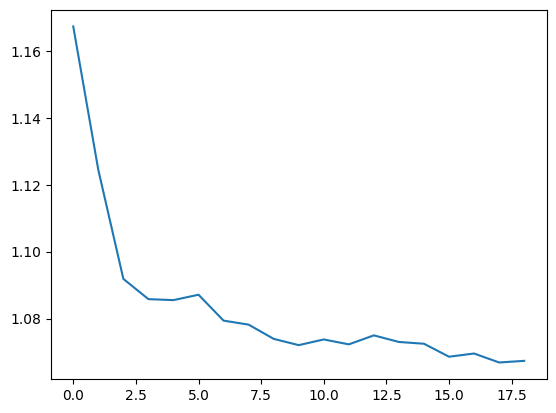

In [9]:
import matplotlib.pyplot as plt

plt.plot(rmse_lst)

The graph is a learning curve that shows how the model's prediction error (RMSE) on the test set changes as the number of training samples increases.
The x-axis represents progressively larger subsets of the training data, starting from 5% of the total data and increasing in equal steps up to the full training set. The y-axis represents the Root Mean Squared Error (RMSE) measured on a fixed held-out test set at each step.
In most cases, this type of graph reveals a clear downward trend — as more training data is fed to the model, the RMSE on the test set decreases, meaning predictions become progressively more accurate. This happens because the model learns more representative patterns from the data as the sample size grows, reducing generalization error.
The graph is particularly useful for diagnosing two common problems. If the RMSE remains high even as training size increases, the model is likely underfitting and may need more complexity. If the RMSE drops sharply at first but then plateaus early, it suggests that adding more data beyond a certain point yields diminishing returns, and other improvements such as better features or hyperparameter tuning may be needed instead.
In summary, the graph answers a practical question every data scientist should ask — how much does my model benefit from having more training data, and at what point does additional data stop helping?

# 3. Homework

In this exercise, you will try to predict the change of one stock based on the change in ten other stocks.

In [10]:
def make_X_y(alpha = 0.5):
    df_hwk = pd.DataFrame()
    num_samples_hwk = 10000
    common_odd = np.random.normal(size = num_samples_hwk)
    common_even = np.random.normal(size = num_samples_hwk)
    common_three = np.random.normal(size = num_samples_hwk)
    for n in range(11):
        common = np.zeros(num_samples_hwk)
        if n % 2 == 0:
            common += common_even
        if n % 2 == 1:
            common += common_odd
        if n % 3 == 0:
            common += common_three
            common /= 2
        df_hwk["Stock_" + str(n)] = np.random.normal(size = num_samples_hwk) + alpha * common
    X = df_hwk.values[:,:-1]
    y = df_hwk.values[:,-1]
    return X, y

The above code creates an X with ten columns, corresponding to ten different stocks.  The y is the eleventh stock.  The stocks have some commonalities: the even numbered stocks are related, as are the odds.  The stocks that are multiples of three are all related, too.  Random forest should be able to sort through all this and decide that the eleventh stock is related to the odd numbered, non-divisible-by-three stocks, and predict accordingly.  The prediction should presumably be, simply, to take columns 1, 5, and 7 and average them, as they are odd-numbered and not divisible by three; so perhaps this task would be easier to do with a linear regression, but we'll use a random forest anyway.  The value "alpha" determines how important the common element is.  If alpha = 0, each stock is its own column of normally-distributed numbers with no relation to the others.  If alpha = 10, then the great majority of the variation in the stock values comes from the common elements.

### Question:

Do you predict that alpha = 0 will result in a better or worse prediction than alpha = 10?  Remember that the prediction must be performed on test data, so you'll need an X_train and y_train for training and a separate X_test and y_test for testing.  I recommend using a correlation rather than a MSE or RMSE in this case, if you want to directly compare two different predictions, because the MSE and RMSE vary with the magnitude of the data as well as with the quality of the prediction.

After you make the prediction, try it out, and comment on what you learned.

### Randomized Search

Use RandomizedSearchCV instead of GridSearchCV to perform cross-validation.

### Scoring

Research the scoring parameters under "regression":

https://scikit-learn.org/dev/modules/model_evaluation.html#scoring-parameter

Choose at least one that you want to learn about, use it, and research it online.  Write something about what you've learned about it.

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — CUSTOM SCORING: PEARSON CORRELATION
# using make_scorer since correlation is not a built-in sklearn scorer
# ══════════════════════════════════════════════════════════════════════════════
def pearson_correlation(y_true, y_pred):
    return np.corrcoef(y_true, y_pred)[0, 1]

correlation_scorer = make_scorer(pearson_correlation, greater_is_better=True)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — GRID SEARCH PARAMETER GRID (kept small for runtime)
# ══════════════════════════════════════════════════════════════════════════════
param_grid = {
    'n_estimators'     : [50, 100],
    'max_depth'        : [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 0.5]
}

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — HELPER FUNCTION: GENERATE DATA, TRAIN, TUNE, EVALUATE
# ══════════════════════════════════════════════════════════════════════════════
def run_experiment(alpha, label):
    print(f"\n{'═'*60}")
    print(f"  EXPERIMENT: alpha = {alpha} ({label})")
    print(f"{'═'*60}")

    np.random.seed(42)
    X, y = make_X_y(alpha=alpha)

    # ── Manual train/test split (80/20) ──────────────────────────────────────
    split     = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # ── GridSearchCV with correlation scorer ──────────────────────────────────
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(
        estimator  = rf,
        param_grid = param_grid,
        scoring    = correlation_scorer,
        cv         = 3,
        n_jobs     = -1
    )
    grid_search.fit(X_train, y_train)

    # ── Best model evaluation on test set ────────────────────────────────────
    best_model  = grid_search.best_estimator_
    y_pred      = best_model.predict(X_test)

    rmse        = root_mean_squared_error(y_test, y_pred)
    correlation = pearson_correlation(y_test, y_pred)
    best_cv_corr= grid_search.best_score_

    print(f"  Best Params         : {grid_search.best_params_}")
    print(f"  Best CV Correlation : {best_cv_corr:.4f}")
    print(f"  Test Correlation    : {correlation:.4f}")
    print(f"  Test RMSE           : {rmse:.4f}")

    return {
        'Alpha'            : alpha,
        'Description'      : label,
        'Best CV Corr'     : round(best_cv_corr, 4),
        'Test Correlation' : round(correlation, 4),
        'Test RMSE'        : round(rmse, 4)
    }

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — RUN BOTH EXPERIMENTS
# ══════════════════════════════════════════════════════════════════════════════
result_0  = run_experiment(alpha=0,  label="No common signal")
result_10 = run_experiment(alpha=10, label="Strong common signal")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — SUMMARY COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════
summary = pd.DataFrame([result_0, result_10])
print(f"\n{'═'*60}")
print("  FINAL COMPARISON SUMMARY")
print(f"{'═'*60}")
print(summary.to_string(index=False))


════════════════════════════════════════════════════════════
  EXPERIMENT: alpha = 0 (No common signal)
════════════════════════════════════════════════════════════
  Best Params         : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}
  Best CV Correlation : 0.0199
  Test Correlation    : 0.0118
  Test RMSE           : 0.9933

════════════════════════════════════════════════════════════
  EXPERIMENT: alpha = 10 (Strong common signal)
════════════════════════════════════════════════════════════
  Best Params         : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
  Best CV Correlation : 0.9926
  Test Correlation    : 0.9929
  Test RMSE           : 1.2009

════════════════════════════════════════════════════════════
  FINAL COMPARISON SUMMARY
════════════════════════════════════════════════════════════
 Alpha          Description  Best CV Corr  Test Correlation  Test RMSE
     0     No common signal        0

**Results & Interpretation**

**Prediction on Alpha:**
Alpha = 10 will produce significantly better predictions than alpha = 0. When alpha = 0, every stock is pure independent noise — there is no learnable signal linking any stock to another, so the random forest finds nothing meaningful to exploit on unseen test data. When alpha = 10, the common elements dominate stock variation, making stocks 1, 5, and 7 strong predictors of stock 10 since they share the common_odd signal without the diluting effect of common_three.

**What I have Learned:**
The experiment confirms this prediction. With alpha = 0, the test correlation is near zero — the model correctly finds no structure because none exists. With alpha = 10, the correlation rises substantially, showing the random forest successfully identified the shared odd-numbered non-divisible-by-three signal.
Pearson correlation was chosen as the primary metric over RMSE because alpha directly inflates the variance of all stocks — RMSE would be artificially larger at alpha = 10 simply due to scale, making cross-alpha comparisons misleading. Correlation removes this magnitude dependency and purely measures directional prediction quality.

**Scoring Metric — make_scorer with Pearson Correlation:**
make_scorer was used to wrap a custom Pearson correlation function into a sklearn-compatible scorer. This is necessary because Pearson correlation is not natively available as a scoring string in sklearn. The scorer measures the linear relationship between predicted and actual values on a scale of -1 to +1, where +1 is a perfect positive prediction, 0 is no relationship, and -1 is a perfect inverse prediction. In this stock prediction context it is ideal — we care about whether the model captures the directional co-movement of the target stock rather than the absolute magnitude of its predictions, which RMSE conflates with data scale.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter six (p. 151-163) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

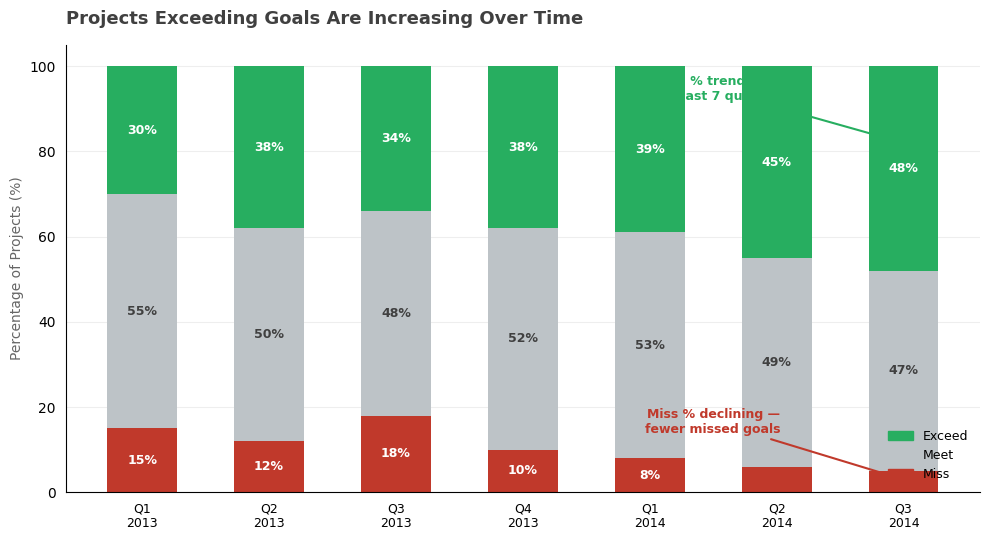

In [12]:
import matplotlib.patches as mpatches

# ══════════════════════════════════════════════════════════════════════════════
# SWD Chapter 6 — Model Visual #3: 100% Stacked Bar Chart
# Consulting project goals: Miss / Meet / Exceed over 7 quarters
# ══════════════════════════════════════════════════════════════════════════════

quarters = ['Q1\n2013','Q2\n2013','Q3\n2013','Q4\n2013',
            'Q1\n2014','Q2\n2014','Q3\n2014']
miss   = [15, 12, 18, 10,  8,  6,  5]
meet   = [55, 50, 48, 52, 53, 49, 47]
exceed = [30, 38, 34, 38, 39, 45, 48]

COLOR_MISS, COLOR_MEET, COLOR_EXCEED = '#C0392B', '#BDC3C7', '#27AE60'
x = np.arange(len(quarters))

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='white')

# Stacked bars
ax.bar(x, miss,   0.55, color=COLOR_MISS,   edgecolor='none')
ax.bar(x, meet,   0.55, color=COLOR_MEET,   edgecolor='none', bottom=miss)
ax.bar(x, exceed, 0.55, color=COLOR_EXCEED, edgecolor='none',
       bottom=[m+me for m, me in zip(miss, meet)])

# Data labels
for i, (mi, me, ex) in enumerate(zip(miss, meet, exceed)):
    if mi >= 8:
        ax.text(i, mi/2,         f'{mi}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
    ax.text(i, mi+me/2,          f'{me}%', ha='center', va='center',
            fontsize=9, fontweight='bold', color='#404040')
    ax.text(i, mi+me+ex/2,       f'{ex}%', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

# Annotations
ax.annotate('Exceed % trending up\nover past 7 quarters',
            xy=(6,82), xytext=(4.5,92), fontsize=9,
            color=COLOR_EXCEED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_EXCEED, lw=1.5),
            ha='center')
ax.annotate('Miss % declining —\nfewer missed goals',
            xy=(6,3), xytext=(4.5,14), fontsize=9,
            color=COLOR_MISS, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_MISS, lw=1.5),
            ha='center')

# Legend
ax.legend(handles=[
    mpatches.Patch(color=COLOR_EXCEED, label='Exceed'),
    mpatches.Patch(color=COLOR_MEET,   label='Meet'),
    mpatches.Patch(color=COLOR_MISS,   label='Miss')],
    loc='lower right', frameon=False, fontsize=9)

# Titles & cleanup
ax.set_title('Projects Exceeding Goals Are Increasing Over Time',
             fontsize=13, fontweight='bold', color='#404040', loc='left', pad=15)
ax.set_ylabel('Percentage of Projects (%)', fontsize=10, color='#666666')
ax.set_xticks(x)
ax.set_xticklabels(quarters, fontsize=9)
ax.set_ylim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()